In [33]:
import pyvista as pv
import pandas as pd
import meshio
import numpy as np
import matplotlib.pyplot as plt

pv.set_jupyter_backend('trame')

In [34]:
filename = "../Examples/Pneumatics-examples/Hollow Sphere Cavity/sim_outputs/sim_with_cavity_try1/sim.pvd"

reader = pv.get_reader(filename)

In [35]:
beginning_time = 0
reader.set_active_time_value(beginning_time)
multiblock = reader.read()[0]
vmesh_t = multiblock[0][0]
vmesh_t_warped = vmesh_t.warp_by_vector("solution")
vmesh_t_warped.slice_orthogonal().plot()

Widget(value='<iframe src="http://localhost:45005/index.html?ui=P_0x76896013abd0_5&reconnect=auto" class="pyvi…

In [36]:
scrub_percent = 90

i_quartertime = int(len(reader.time_values) * scrub_percent/100)
t_quartertime = reader.time_values[i_quartertime]
reader.set_active_time_value(t_quartertime)

multiblock = reader.read()[0]
vmesh_t = multiblock[0][0]
vmesh_t_warped = vmesh_t.warp_by_vector("solution")
vmesh_t_warped.slice_orthogonal().plot()
# slices = vmesh_t_warped.slice_orthogonal()
# slices.plot()

Widget(value='<iframe src="http://localhost:45005/index.html?ui=P_0x768960156270_6&reconnect=auto" class="pyvi…

In [37]:
volume_mesh = multiblock[0][0]
surface_mesh = multiblock[1][0]

In [38]:
volume_mesh

UnstructuredGrid (0x76899c310700)
  N Cells:    19309
  N Points:   77236
  X Bounds:   -9.986e-02, 9.997e-02
  Y Bounds:   -1.200e-01, 1.200e-01
  Z Bounds:   -9.999e-02, 9.991e-02
  N Arrays:   21

In [39]:
surface_mesh

UnstructuredGrid (0x76899c35e6e0)
  N Cells:    7770
  N Points:   23310
  X Bounds:   -9.986e-02, 9.997e-02
  Y Bounds:   -1.200e-01, 1.200e-01
  Z Bounds:   -9.999e-02, 9.991e-02
  N Arrays:   12

In [40]:
## Load point-id-to-faces mapping from surface_selections
ss_filename = "../Examples/Pneumatics-examples/Hollow Sphere Cavity/surface_selection/surface_selections.txt"
names = ["id_surf", "id_p1", "id_p2", "id_p3"]
df_surf_select = pd.read_csv(ss_filename, delim_whitespace=True, header=None, names=names)

id_channel_surf = 2
df_channel_select = df_surf_select[df_surf_select["id_surf"]==id_channel_surf]

In [41]:
# Do these indices correlate with the points we get by reading the paraview files?
# Check the range of the surface selection ids
print(f"Maximum ID being selected: {np.max(df_channel_select)}")

Maximum ID being selected: 4567


In [42]:
# Check if the vertex and face numbers we are loading with pyvista square 
# with our notion of V and F from meshio
mesh_path = "../Examples/Pneumatics-examples/Hollow Sphere Cavity/meshes/HollowSphere - part.msh"
mesh = meshio.read(mesh_path)
mesh

<meshio mesh object>
  Number of points: 5241
  Number of cells:
    tetra: 19309
  Cell data: color

So we see that:
1. the surface selection point ids square with the number of points in the mesh
2. the number of points in the paraview meshes are way higher than in the .msh file

This begs the question - what are we actually reading when we read the paraview mesh?

We should also retry this on a different, more freshly-run file, so that I can ensure that the meshes line up

---
## 1/1 tests with surface vtu data

In [43]:
side_ids = np.unique(surface_mesh["sidesets"])
id_unassigned = side_ids[-1]
id_actual_max = side_ids[-2]
surface_mesh.point_data["sidesets"][surface_mesh["sidesets"] == id_unassigned] = id_actual_max + 1

In [44]:
pl = pv.Plotter()
smesh_sliced = surface_mesh.slice_orthogonal()

num_colors = 4
discrete_cmap = plt.get_cmap('viridis', num_colors)

pl.add_mesh(smesh_sliced, scalars="sidesets", cmap=discrete_cmap)
pl.show()
# surface_mesh.slice_orthogonal().plot()

Widget(value='<iframe src="http://localhost:45005/index.html?ui=P_0x76899c380bf0_7&reconnect=auto" class="pyvi…

In [45]:
mask_mesh_interior = surface_mesh["sidesets"] == 2
i_mask_interior = np.nonzero(mask_mesh_interior)
smesh_warped = surface_mesh.warp_by_vector("solution")
mesh_interior = smesh_warped.extract_points(i_mask_interior, include_cells=True)

In [46]:
mesh_interior.plot()

Widget(value='<iframe src="http://localhost:45005/index.html?ui=P_0x76899c382c30_8&reconnect=auto" class="pyvi…

In [47]:
def get_mb_at_time(reader, t):
    reader.set_active_time_value(t)
    multiblock = reader.read()[0]
    return multiblock

def get_volume_at_time(reader, t, id_interior):
    # t must be an element within reader.time_values
    multiblock = get_mb_at_time(reader, t)

    smesh_t = multiblock[1][0]

    # Todo - we only need to compute this mesh once, could cache for efficiency if needed
    mask_mesh_interior = smesh_t["sidesets"] == id_interior
    i_mask_interior = np.nonzero(mask_mesh_interior)
    
    smesh_warped_t = smesh_t.warp_by_vector("solution")
    mesh_interior_t = smesh_warped_t.extract_points(i_mask_interior, include_cells=True)
    volume_t = mesh_interior_t.extract_surface().volume

    # mesh_interior_t.plot()

    return volume_t

In [50]:
filename = "../Examples/Pneumatics-examples/Hollow Sphere Cavity/sim_outputs/sim_with_cavity_try1/sim.pvd"
reader = pv.get_reader(filename)

id_interior = 2
v_0 = get_volume_at_time(reader, 0, id_interior)
ps = []
vs = []
for t in reader.time_values:
    v_t = get_volume_at_time(reader, t, id_interior)
    p_t_ratio = v_0/v_t
    vs.append(v_t)
    ps.append(p_t_ratio)
    print(f"t = {t:.4f}, v_t: {v_t:.8f}, p_t = {p_t_ratio:.8f} * p_0")

t = 0.0000, v_t: 0.00213292, p_t = 1.00000000 * p_0
t = 0.0125, v_t: 0.00222339, p_t = 0.95930779 * p_0
t = 0.0250, v_t: 0.00222141, p_t = 0.96016446 * p_0
t = 0.0375, v_t: 0.00221894, p_t = 0.96123482 * p_0
t = 0.0500, v_t: 0.00221654, p_t = 0.96227574 * p_0
t = 0.0625, v_t: 0.00221407, p_t = 0.96334709 * p_0
t = 0.0750, v_t: 0.00221154, p_t = 0.96445053 * p_0
t = 0.0875, v_t: 0.00220893, p_t = 0.96558702 * p_0
t = 0.1000, v_t: 0.00220626, p_t = 0.96675761 * p_0
t = 0.1125, v_t: 0.00220351, p_t = 0.96796343 * p_0
t = 0.1250, v_t: 0.00220069, p_t = 0.96920557 * p_0
t = 0.1375, v_t: 0.00219779, p_t = 0.97048519 * p_0
t = 0.1500, v_t: 0.00219480, p_t = 0.97180345 * p_0
t = 0.1625, v_t: 0.00219174, p_t = 0.97316152 * p_0
t = 0.1750, v_t: 0.00218859, p_t = 0.97456062 * p_0
t = 0.1875, v_t: 0.00218536, p_t = 0.97600197 * p_0
t = 0.2000, v_t: 0.00218204, p_t = 0.97748681 * p_0
t = 0.2125, v_t: 0.00217863, p_t = 0.97901641 * p_0
t = 0.2250, v_t: 0.00217513, p_t = 0.98059205 * p_0
t = 0.2375, 

Text(0, 0.5, 'Pressure [atm]')

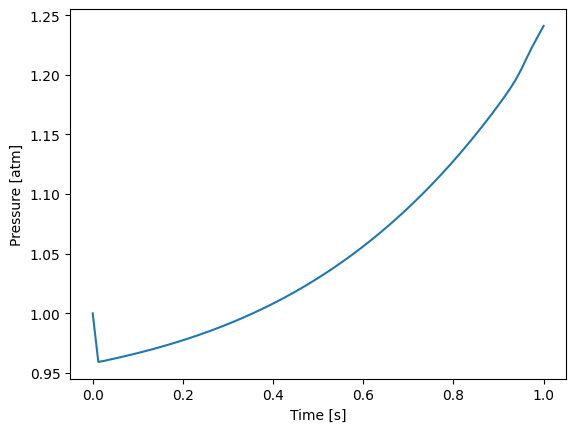

In [53]:
plt.plot(reader.time_values, ps)
plt.xlabel("Time [s]")
plt.ylabel("Pressure [atm]")

Text(0, 0.5, 'Volume [m^3]')

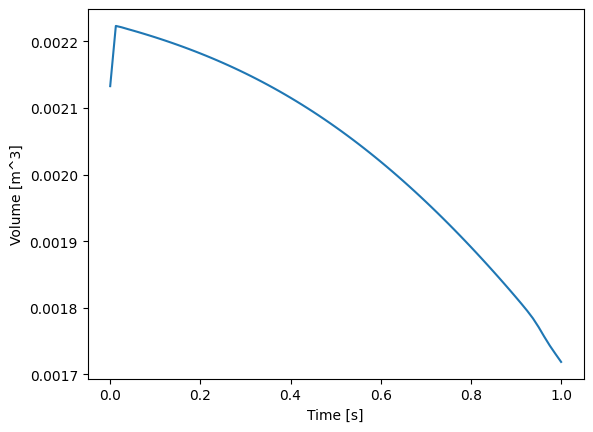

In [55]:
plt.plot(reader.time_values, vs)
plt.xlabel("Time [s]")
plt.ylabel("Volume [m^3]")